In [1]:
import os
import sys
from pathlib import Path

import yaml
from pyspark.sql import functions as F

# Find project root automatically
project_root = Path.cwd()
while not (project_root / "configs").exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: /home/ubuntu/renewable-energy-forecasting-pipeline


In [2]:
PROJECT_USER_CONFIG = os.environ.get(
    "PROJECT_USER_CONFIG",
    "configs/users/syed.yaml",
)

config_path = project_root / PROJECT_USER_CONFIG

print("Loading config from:", config_path)

with open(config_path, "r") as f:
    user_config = yaml.safe_load(f)

bucket = user_config["aws"]["project_bucket"]
gold_prefix = user_config["aws"]["gold_prefix"]

bucket, gold_prefix

Loading config from: /home/ubuntu/renewable-energy-forecasting-pipeline/configs/users/syed.yaml


('syed-datsbd-s2026', 'gold/wind')

In [3]:
from src.common.spark_utils import get_spark_session

spark = get_spark_session(
    app_name="layer6_partC_wind_model_validation"
)

spark.sparkContext.setLogLevel("WARN")

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ubuntu/.ivy2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-7bd8b53d-6d51-49de-b6e3-b0f5080d867c;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 404ms :: artifacts dl 12ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	--------------------------------

In [4]:
gold_root = f"s3a://{bucket}/{gold_prefix}"

paths = {
    "station_hourly": f"{gold_root}/station/hourly",
    "station_daily": f"{gold_root}/station/daily",
    "region_daily": f"{gold_root}/region/daily",
    "region_monthly": f"{gold_root}/region/monthly",
}

paths

{'station_hourly': 's3a://syed-datsbd-s2026/gold/wind/station/hourly',
 'station_daily': 's3a://syed-datsbd-s2026/gold/wind/station/daily',
 'region_daily': 's3a://syed-datsbd-s2026/gold/wind/region/daily',
 'region_monthly': 's3a://syed-datsbd-s2026/gold/wind/region/monthly'}

In [5]:
station_hourly = spark.read.parquet(paths["station_hourly"])
station_daily = spark.read.parquet(paths["station_daily"])
region_daily = spark.read.parquet(paths["region_daily"])
region_monthly = spark.read.parquet(paths["region_monthly"])

print("Gold tables loaded successfully.")

26/04/28 04:25:59 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Gold tables loaded successfully.


In [6]:
print("station_hourly")
station_hourly.printSchema()

print("station_daily")
station_daily.printSchema()

print("region_daily")
region_daily.printSchema()

print("region_monthly")
region_monthly.printSchema()

station_hourly
root
 |-- station_id: string (nullable = true)
 |-- timestamp_utc: timestamp (nullable = true)
 |-- date_utc: date (nullable = true)
 |-- month: integer (nullable = true)
 |-- wind_speed_ms: double (nullable = true)
 |-- normalized_power: double (nullable = true)
 |-- wind_power_density_wm2: double (nullable = true)
 |-- year: integer (nullable = true)
 |-- state: string (nullable = true)

station_daily
root
 |-- station_id: string (nullable = true)
 |-- date_utc: date (nullable = true)
 |-- month: integer (nullable = true)
 |-- daily_capacity_factor: double (nullable = true)
 |-- hourly_observation_count: long (nullable = true)
 |-- mean_wind_speed_ms: double (nullable = true)
 |-- std_wind_speed_ms: double (nullable = true)
 |-- min_wind_speed_ms: double (nullable = true)
 |-- max_wind_speed_ms: double (nullable = true)
 |-- is_valid_daily_station_index: boolean (nullable = true)
 |-- wind_power_class: integer (nullable = true)
 |-- year: integer (nullable = true)
 |--

In [7]:
counts = {
    "station_hourly": station_hourly.count(),
    "station_daily": station_daily.count(),
    "region_daily": region_daily.count(),
    "region_monthly": region_monthly.count(),
}

counts

{'station_hourly': 812991212,
 'station_daily': 19430672,
 'region_daily': 537449,
 'region_monthly': 17664}

In [8]:
region_daily.select(
    F.min("year").alias("min_year"),
    F.max("year").alias("max_year"),
    F.countDistinct("year").alias("year_count"),
    F.countDistinct("state").alias("state_count"),
).show()

+--------+--------+----------+-----------+
|min_year|max_year|year_count|state_count|
+--------+--------+----------+-----------+
|    1995|    2025|        31|         48|
+--------+--------+----------+-----------+



In [9]:
station_hourly.select(
    F.min("normalized_power").alias("min_normalized_power"),
    F.max("normalized_power").alias("max_normalized_power"),
    F.avg("normalized_power").alias("avg_normalized_power"),
).show()

region_daily.select(
    F.min("daily_region_capacity_factor").alias("min_daily_cf"),
    F.max("daily_region_capacity_factor").alias("max_daily_cf"),
    F.avg("daily_region_capacity_factor").alias("avg_daily_cf"),
).show()

region_monthly.select(
    F.min("monthly_region_capacity_factor").alias("min_monthly_cf"),
    F.max("monthly_region_capacity_factor").alias("max_monthly_cf"),
    F.avg("monthly_region_capacity_factor").alias("avg_monthly_cf"),
).show()

+--------------------+--------------------+--------------------+
|min_normalized_power|max_normalized_power|avg_normalized_power|
+--------------------+--------------------+--------------------+
|                 0.0|                 1.0| 0.04081125036654442|
+--------------------+--------------------+--------------------+



+------------+------------+-------------------+
|min_daily_cf|max_daily_cf|       avg_daily_cf|
+------------+------------+-------------------+
|         0.0|    0.900287|0.04260320329928978|
+------------+------------+-------------------+



+--------------+--------------+--------------------+
|min_monthly_cf|max_monthly_cf|      avg_monthly_cf|
+--------------+--------------+--------------------+
|      0.001662|      0.274203|0.042682438915307985|
+--------------+--------------+--------------------+



In [10]:
bad_hourly = station_hourly.where(
    (F.col("normalized_power") < 0)
    | (F.col("normalized_power") > 1)
).count()

bad_daily_region = region_daily.where(
    (F.col("daily_region_capacity_factor") < 0)
    | (F.col("daily_region_capacity_factor") > 1)
).count()

bad_monthly_region = region_monthly.where(
    (F.col("monthly_region_capacity_factor") < 0)
    | (F.col("monthly_region_capacity_factor") > 1)
).count()

bad_hourly, bad_daily_region, bad_monthly_region

(0, 0, 0)

In [11]:
seasonal_monthly = (
    region_monthly
    .groupBy("month")
    .agg(
        F.round(F.avg("monthly_region_capacity_factor"), 6).alias("avg_monthly_cf"),
        F.round(F.avg("monthly_mean_wind_speed_ms"), 4).alias("avg_wind_speed_ms"),
        F.count("*").alias("rows"),
    )
    .orderBy("month")
)

seasonal_monthly.show(12)

+-----+--------------+-----------------+----+
|month|avg_monthly_cf|avg_wind_speed_ms|rows|
+-----+--------------+-----------------+----+
|    1|      0.051338|            3.535|1488|
|    2|      0.054658|           3.6452|1488|
|    3|      0.060766|           3.8397|1488|
|    4|      0.063079|           3.8994|1488|
|    5|        0.0451|           3.4596|1488|
|    6|      0.034115|           3.1381|1488|
|    7|      0.023911|           2.8263|1488|
|    8|      0.021338|           2.6783|1488|
|    9|      0.027154|           2.8327|1440|
|   10|      0.038405|           3.1199|1440|
|   11|      0.044717|           3.2971|1440|
|   12|       0.04718|           3.3723|1440|
+-----+--------------+-----------------+----+



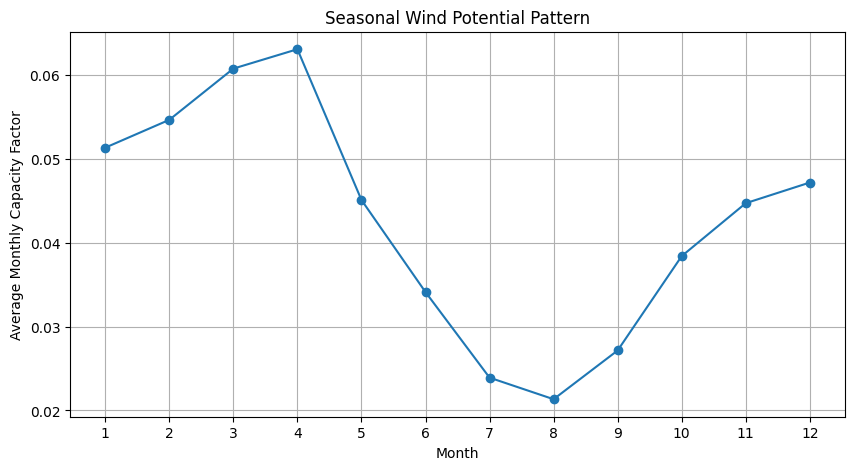

In [12]:
import matplotlib.pyplot as plt

seasonal_pd = seasonal_monthly.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(seasonal_pd["month"], seasonal_pd["avg_monthly_cf"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average Monthly Capacity Factor")
plt.title("Seasonal Wind Potential Pattern")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [13]:
top_states = (
    region_monthly
    .groupBy("state")
    .agg(
        F.round(F.avg("monthly_region_capacity_factor"), 6).alias("avg_monthly_cf"),
        F.round(F.avg("monthly_mean_wind_speed_ms"), 4).alias("avg_wind_speed_ms"),
        F.count("*").alias("month_count"),
    )
    .orderBy(F.desc("avg_monthly_cf"))
)

top_states.show(20)

+-----+--------------+-----------------+-----------+
|state|avg_monthly_cf|avg_wind_speed_ms|month_count|
+-----+--------------+-----------------+-----------+
|   ND|      0.092272|           4.6982|        368|
|   SD|      0.089094|           4.5054|        368|
|   KS|      0.083958|           4.5597|        368|
|   NE|      0.078505|           4.3294|        368|
|   MT|       0.07843|           4.0629|        368|
|   WY|      0.077021|           3.9055|        368|
|   NM|       0.06876|            4.011|        368|
|   IA|      0.065962|           4.1542|        368|
|   CO|       0.06356|           3.7411|        368|
|   OK|      0.062456|            3.998|        368|
|   TX|      0.055899|           3.9152|        368|
|   MN|          0.05|           3.6193|        368|
|   RI|      0.049693|           3.7554|        368|
|   DE|      0.048389|           3.6918|        368|
|   MA|       0.04808|           3.6162|        368|
|   IL|      0.047616|           3.6317|      

In [14]:
bottom_states = top_states.orderBy("avg_monthly_cf")
bottom_states.show(20)

+-----+--------------+-----------------+-----------+
|state|avg_monthly_cf|avg_wind_speed_ms|month_count|
+-----+--------------+-----------------+-----------+
|   GA|      0.013475|            2.282|        368|
|   WV|      0.015278|           2.2824|        368|
|   AL|       0.01661|           2.4683|        368|
|   SC|      0.017603|            2.586|        368|
|   TN|      0.017762|            2.474|        368|
|   VT|      0.018586|           2.3549|        368|
|   KY|      0.020153|           2.6578|        368|
|   MS|      0.020307|           2.6438|        368|
|   NC|      0.020922|           2.5211|        368|
|   AR|      0.023371|           2.8046|        368|
|   VA|      0.027231|           2.7724|        368|
|   ME|      0.028226|           2.9115|        368|
|   PA|      0.028288|           2.9549|        368|
|   FL|      0.028321|           3.0908|        368|
|   WA|       0.02981|           2.8226|        368|
|   OR|      0.031237|           2.7748|      

In [15]:
region_daily.select(
    F.min("daily_region_capacity_factor").alias("min_daily_cf"),
    F.expr("percentile_approx(daily_region_capacity_factor, 0.25)").alias("p25"),
    F.expr("percentile_approx(daily_region_capacity_factor, 0.50)").alias("median"),
    F.expr("percentile_approx(daily_region_capacity_factor, 0.75)").alias("p75"),
    F.max("daily_region_capacity_factor").alias("max_daily_cf"),
).show()

+------------+--------+--------+--------+------------+
|min_daily_cf|     p25|  median|     p75|max_daily_cf|
+------------+--------+--------+--------+------------+
|         0.0|0.008817|0.023325|0.053362|    0.900287|
+------------+--------+--------+--------+------------+



In [16]:
region_monthly.groupBy("is_valid_monthly_region_index").count().show()

+-----------------------------+-----+
|is_valid_monthly_region_index|count|
+-----------------------------+-----+
|                         true|17664|
+-----------------------------+-----+



In [17]:
coverage_by_year = (
    region_daily
    .groupBy("year")
    .agg(
        F.countDistinct("state").alias("state_count"),
        F.round(F.avg("station_count"), 2).alias("avg_daily_station_count"),
        F.sum("total_hourly_observations").alias("total_hourly_observations"),
    )
    .orderBy("year")
)

coverage_by_year.show(40)

+----+-----------+-----------------------+-------------------------+
|year|state_count|avg_daily_station_count|total_hourly_observations|
+----+-----------+-----------------------+-------------------------+
|1995|         48|                  21.04|                  8518063|
|1996|         48|                  21.19|                  8701920|
|1997|         48|                  22.13|                  9033463|
|1998|         48|                  11.28|                  5089296|
|1999|         48|                   13.7|                  6072057|
|2000|         48|                  15.08|                  6804497|
|2001|         48|                  15.57|                  6668211|
|2002|         48|                  17.41|                  9168618|
|2003|         48|                  18.18|                 10502069|
|2004|         48|                  20.85|                 13781297|
|2005|         48|                  25.36|                 17863984|
|2006|         48|                

In [18]:
low_coverage = (
    region_monthly
    .where(F.col("daily_observation_count") < 15)
    .select(
        "state",
        "year",
        "month",
        "daily_observation_count",
        "avg_station_count",
        "monthly_region_capacity_factor",
    )
    .orderBy("year", "state", "month")
)

low_coverage.show(50, truncate=False)

+-----+----+-----+-----------------------+-----------------+------------------------------+
|state|year|month|daily_observation_count|avg_station_count|monthly_region_capacity_factor|
+-----+----+-----+-----------------------+-----------------+------------------------------+
+-----+----+-----+-----------------------+-----------------+------------------------------+



In [19]:
selected_states = ["TX", "KS", "ND", "CA", "FL", "NY"]

selected_monthly = (
    region_monthly
    .where(F.col("state").isin(selected_states))
    .groupBy("state", "year")
    .agg(
        F.round(F.avg("monthly_region_capacity_factor"), 6).alias("annual_avg_cf"),
        F.round(F.avg("monthly_mean_wind_speed_ms"), 4).alias("annual_avg_wind_speed"),
    )
    .orderBy("state", "year")
)

selected_monthly.show(200)

+-----+----+-------------+---------------------+
|state|year|annual_avg_cf|annual_avg_wind_speed|
+-----+----+-------------+---------------------+
|   CA|1995|     0.041791|               3.2614|
|   CA|1996|     0.045859|               3.4034|
|   CA|1997|     0.045903|               3.4768|
|   CA|1998|     0.043064|               3.3914|
|   CA|1999|     0.043203|               3.2836|
|   CA|2000|     0.037873|               3.1721|
|   CA|2001|     0.036653|               3.3115|
|   CA|2002|     0.040474|               3.1827|
|   CA|2003|     0.035222|               3.0396|
|   CA|2004|     0.036737|               3.0547|
|   CA|2005|     0.029776|               2.8665|
|   CA|2006|     0.031605|               2.8711|
|   CA|2007|     0.035369|                  2.9|
|   CA|2008|     0.036318|               2.8596|
|   CA|2009|      0.03111|               2.7329|
|   CA|2010|     0.033224|               2.8107|
|   CA|2011|     0.031789|                2.751|
|   CA|2012|     0.0

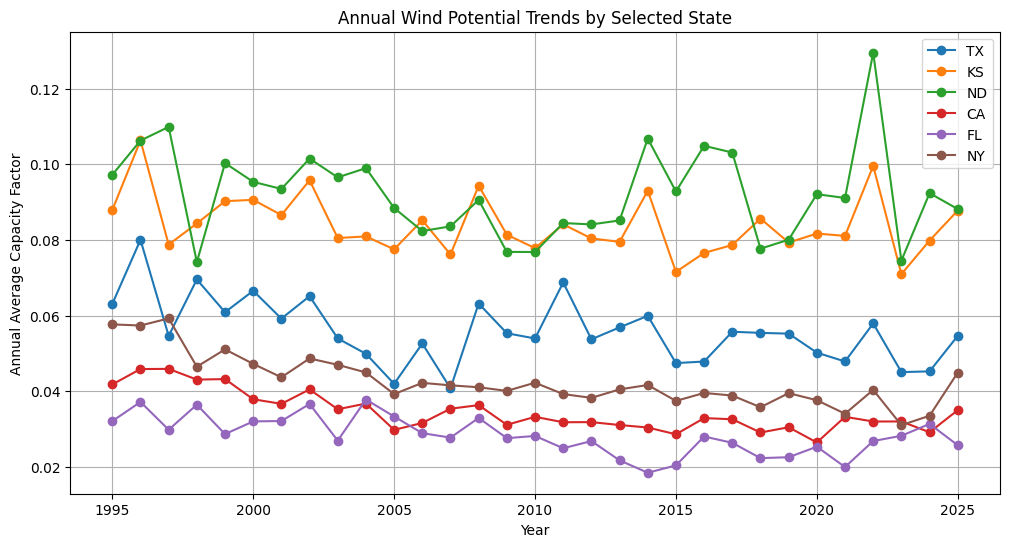

In [20]:
selected_pd = selected_monthly.toPandas()

plt.figure(figsize=(12, 6))

for state in selected_states:
    subset = selected_pd[selected_pd["state"] == state]
    plt.plot(subset["year"], subset["annual_avg_cf"], marker="o", label=state)

plt.xlabel("Year")
plt.ylabel("Annual Average Capacity Factor")
plt.title("Annual Wind Potential Trends by Selected State")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
expected_high_wind_states = ["TX", "OK", "KS", "NE", "ND", "SD", "IA", "WY", "MT"]

expected_high = (
    region_monthly
    .where(F.col("state").isin(expected_high_wind_states))
    .groupBy("state")
    .agg(
        F.round(F.avg("monthly_region_capacity_factor"), 6).alias("avg_monthly_cf"),
        F.round(F.avg("monthly_mean_wind_speed_ms"), 4).alias("avg_wind_speed_ms"),
        F.count("*").alias("month_count"),
    )
    .orderBy(F.desc("avg_monthly_cf"))
)

expected_high.show()

+-----+--------------+-----------------+-----------+
|state|avg_monthly_cf|avg_wind_speed_ms|month_count|
+-----+--------------+-----------------+-----------+
|   ND|      0.092272|           4.6982|        368|
|   SD|      0.089094|           4.5054|        368|
|   KS|      0.083958|           4.5597|        368|
|   NE|      0.078505|           4.3294|        368|
|   MT|       0.07843|           4.0629|        368|
|   WY|      0.077021|           3.9055|        368|
|   IA|      0.065962|           4.1542|        368|
|   OK|      0.062456|            3.998|        368|
|   TX|      0.055899|           3.9152|        368|
+-----+--------------+-----------------+-----------+



In [22]:
validation_summary = {
    "gold_tables_exist_and_readable": all(v > 0 for v in counts.values()),
    "hourly_power_range_valid": bad_hourly == 0,
    "daily_region_capacity_factor_range_valid": bad_daily_region == 0,
    "monthly_region_capacity_factor_range_valid": bad_monthly_region == 0,
}

validation_summary

{'gold_tables_exist_and_readable': True,
 'hourly_power_range_valid': True,
 'daily_region_capacity_factor_range_valid': True,
 'monthly_region_capacity_factor_range_valid': True}

In [23]:
spark.stop()

# Validation Summary

In this notebook, I validated the completed Gold wind tables stored in S3.

## Gold Tables Validated

The following Gold tables were successfully read from S3:

- `gold/wind/station/hourly`
- `gold/wind/station/daily`
- `gold/wind/region/daily`
- `gold/wind/region/monthly`

## Dataset Coverage

Validation confirmed full project coverage:

- Years: 1995–2025
- Year count: 31
- State count: 48 contiguous U.S. states
- Station hourly rows: 812,991,212
- Station daily rows: 19,430,672
- Region daily rows: 537,449
- Region monthly rows: 17,664

## Range Validation

All wind index values stayed within expected physical/model bounds:

- Hourly normalized power min: 0.0
- Hourly normalized power max: 1.0
- Daily regional capacity factor min: 0.0
- Daily regional capacity factor max: 0.900287
- Monthly regional capacity factor min: 0.001662
- Monthly regional capacity factor max: 0.274203

Invalid value checks returned:

```text
bad_hourly = 0
bad_daily_region = 0
bad_monthly_region = 0
````

## Seasonal Pattern Validation

The monthly seasonal pattern is physically plausible.

Average monthly capacity factor is highest in late winter and spring:

* January: 0.051338
* February: 0.054658
* March: 0.060766
* April: 0.063079

It declines through summer:

* July: 0.023911
* August: 0.021338

Then rises again in fall and winter:

* October: 0.038405
* November: 0.044717
* December: 0.047180

This supports the expected pattern that U.S. wind potential is generally stronger in winter/spring and weaker in summer.

## Regional Pattern Validation

Regional differences are physically plausible.

The highest long-run wind potential states were concentrated in the Great Plains and northern interior:

| Rank group | State | Avg monthly capacity factor |
| ---------- | ----- | --------------------------: |
| High       | ND    |                    0.092272 |
| High       | SD    |                    0.089094 |
| High       | KS    |                    0.083958 |
| High       | NE    |                    0.078505 |
| High       | MT    |                    0.078430 |
| High       | WY    |                    0.077021 |
| High       | IA    |                    0.065962 |
| High       | OK    |                    0.062456 |
| High       | TX    |                    0.055899 |

Lower wind potential states were mostly in the Southeast and Appalachian region:

| State | Avg monthly capacity factor |
| ----- | --------------------------: |
| GA    |                    0.013475 |
| WV    |                    0.015278 |
| AL    |                    0.016610 |
| SC    |                    0.017603 |
| TN    |                    0.017762 |

This aligns with expected U.S. wind geography.

## Daily and Monthly Aggregate Behavior

Daily regional capacity factor distribution was reasonable:

* Minimum: 0.0
* 25th percentile: 0.008817
* Median: 0.023325
* 75th percentile: 0.053362
* Maximum: 0.900287

All monthly region rows passed the monthly validity check:

```text
is_valid_monthly_region_index = true: 17,664 rows
```

No low-coverage monthly rows were found.

## Coverage Notes

All years from 1995–2025 contain 48 states.

Hourly observation coverage increases substantially after the early years, with strongest coverage from the mid-2000s onward. The 2025 total is lower because the year is incomplete relative to full historical years.

## Visual Validation

Two visual checks were reviewed:

1. Seasonal wind potential pattern

   * Shows higher wind potential in winter/spring
   * Shows lower wind potential in summer
   * Pattern is physically plausible

2. Annual wind potential trends by selected state

   * ND and KS consistently show high wind potential
   * TX remains moderate-to-high
   * CA, FL, and NY remain lower
   * Differences are consistent with regional wind resource expectations

## Final Validation Result

```python
{
    "gold_tables_exist_and_readable": True,
    "hourly_power_range_valid": True,
    "daily_region_capacity_factor_range_valid": True,
    "monthly_region_capacity_factor_range_valid": True,
}
```

## Conclusion

Validation confirms that:

* the wind power curve is stable
* Gold wind tables exist and are readable from S3
* hourly, daily, and monthly wind indices are within valid ranges
* seasonal patterns are physically plausible
* regional differences match expected U.S. wind geography
* outputs are ready for downstream analysis and ML
